# Detectability of a junction, adjusted for all features at once

The junction and gene features are correlated with each other, so a
generalised estimating equation is fitted per depth with the junction as the
grouping variable. The outcome is whether a junction was detected in a given
patient at that depth. Continuous predictors are z-scored on a common scale,
so an odds ratio is the change in odds per standard deviation. The working
correlation structure is independence with the junction as the grouping
variable, which leaves the coefficients population-averaged and the standard
errors robust to correlation between the repeated measurements of a junction.
The z-scoring uses one scale across all depths, so the odds ratios can be
compared between them.

The models are fitted by `scripts/fit_gee_models.py`, which takes about forty
minutes and writes `data/derived/gee_coefficients.tsv`, one row per depth and
model term. That file is in the repository, so this notebook runs in seconds.

In [1]:
from pathlib import Path

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import pandas as pd

# Locate the top of the clone, so the notebook runs from any directory inside it.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "asdepth").is_dir()), None)
if ROOT is None:
    raise RuntimeError("run this from inside a clone of RNA-Seq_Depth_for_AS")

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

COEFFICIENTS = ROOT / "data" / "derived" / "gee_coefficients.tsv"

# 300M is the depth the junction universe is defined at, so it is the reference
# calibration point rather than a fitted depth, and is left out of the plot.
REFERENCE_DEPTH = 300

# Panel title -> list of (model term, legend label, colour).
PANELS = {
    "log TPM": [("z_log_TPM", "log TPM", "#1f77b4")],
    "Other continuous features": [
        ("z_PSI_fixed", "PSI (fixed)", "#ff7f0e"),
        ("z_Compactness", "Compactness", "#2ca02c"),
        ("z_GC_content", "GC content", "#8c564b"),
    ],
    "Gene type (vs Protein-coding)": [
        ("C(Gene_type)[T.lncRNA]", "lncRNA", "#e377c2"),
        ("C(Gene_type)[T.Pseudogene]", "Pseudogene", "#7f7f7f"),
        ("C(Gene_type)[T.Other]", "Other", "#bcbd22"),
    ],
    "Region (vs CDS)": [
        ("C(Region)[T.5UTR]", "5'UTR", "#17becf"),
        ("C(Region)[T.3UTR]", "3'UTR", "#d62728"),
    ],
    "Binary features": [
        ("Is_fast_evolving[T.True]", "Fast-evolving", "#aec7e8"),
        ("Is_heart_specific[T.True]", "Heart-specific", "#ffbb78"),
    ],
}

In [2]:
coefficients = pd.read_csv(COEFFICIENTS, sep="\t")

depths = [d for d in sorted(coefficients["depth"].unique()) if d != REFERENCE_DEPTH]
print(f"depths fitted: {depths}")

coefficients[["depth", "term", "OR", "OR_low", "OR_high", "p_adj", "sig"]].query(
    "term != 'Intercept'"
).head(12).round(4)

depths fitted: [50, 100, 150, 200, 250]


,depth,term,OR,OR_low,OR_high,p_adj,sig
0,50,C(Gene_type)[T.Other],0.2817,0.1011,0.7855,0.0232,*
1,50,C(Gene_type)[T.Pseudogene],0.4627,0.4226,0.5065,0.0000,***
2,50,C(Gene_type)[T.lncRNA],0.4843,0.4603,0.5095,0.0000,***
3,50,C(Region)[T.3UTR],0.4552,0.4031,0.5140,0.0000,***
4,50,C(Region)[T.5UTR],0.9616,0.9151,1.0106,0.1632,NaN
6,50,Is_fast_evolving[T.True],0.8488,0.7958,0.9053,0.0000,***
7,50,Is_heart_specific[T.True],0.9764,0.7697,1.2388,0.8442,NaN
8,50,z_Compactness,0.9856,0.9568,1.0153,0.3697,NaN
9,50,z_GC_content,0.7894,0.7727,0.8065,0.0000,***
10,50,z_PSI_fixed,1.0731,1.0552,1.0913,0.0000,***


## Odds ratios by depth

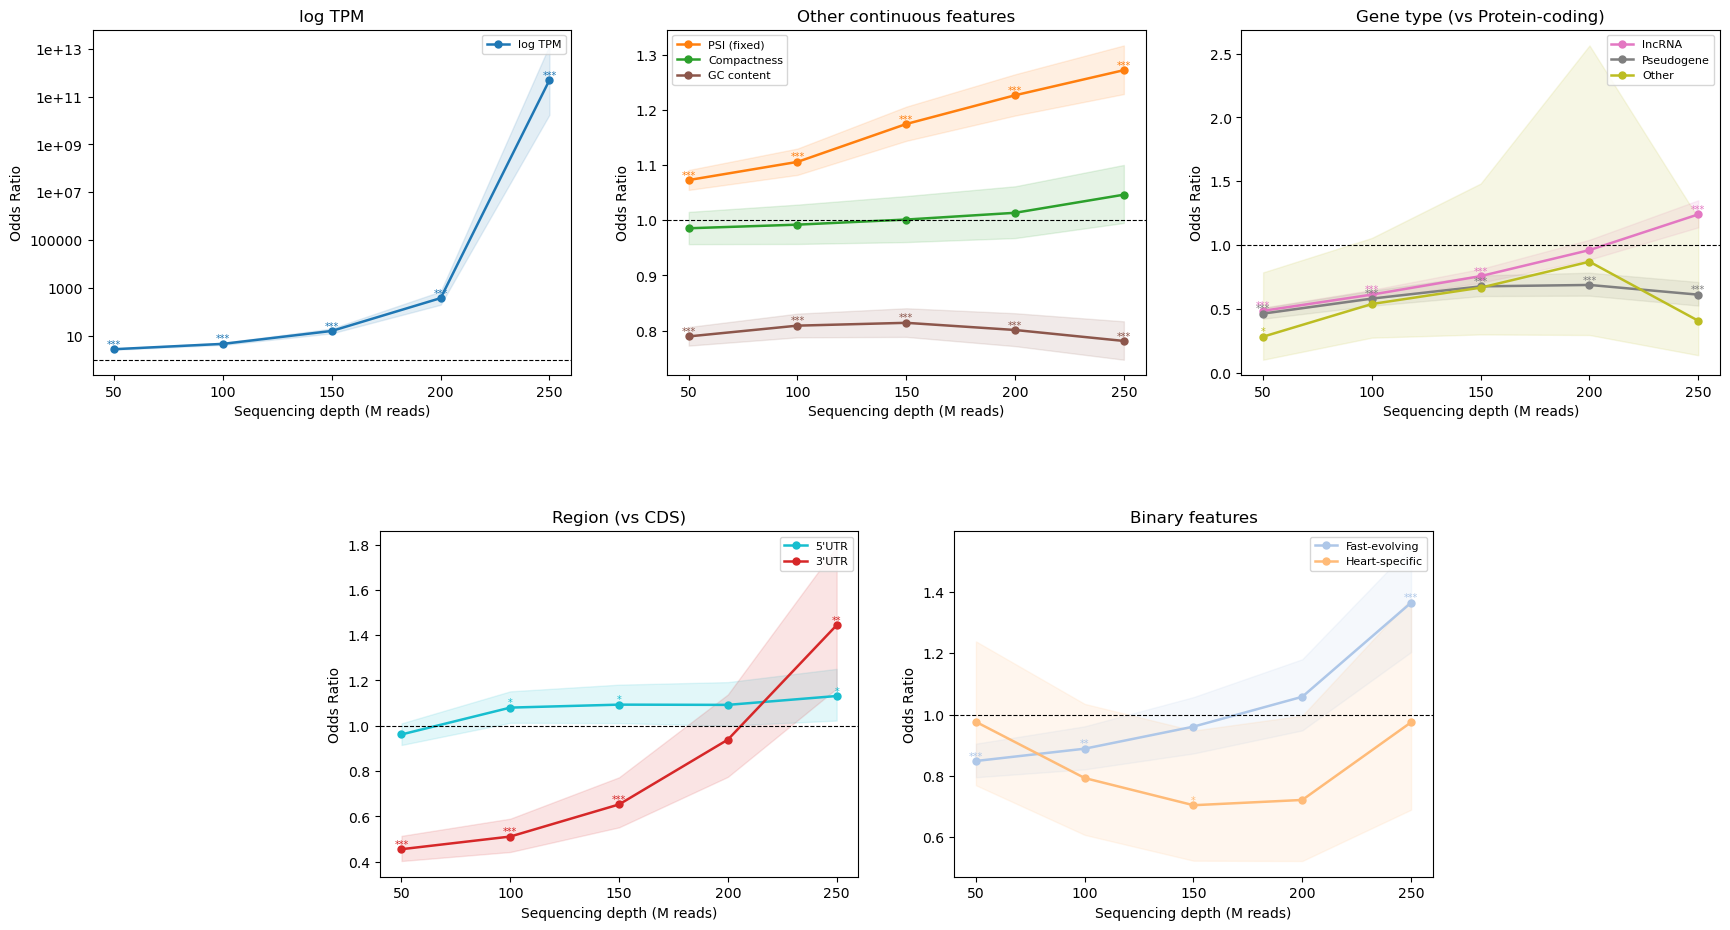

In [3]:
def draw(axes, title, terms):
    for term, label, color in terms:
        odds, low, high, x = [], [], [], []
        for depth in depths:
            row = coefficients[(coefficients["depth"] == depth)
                               & (coefficients["term"] == term)]
            if row.empty:
                continue
            odds.append(row["OR"].values[0])
            low.append(row["OR_low"].values[0])
            high.append(row["OR_high"].values[0])
            x.append(depth)
            marker = row["sig"].values[0]
            if isinstance(marker, str) and marker:
                axes.text(depth, row["OR"].values[0], marker,
                          ha="center", va="bottom", fontsize=7, color=color)
        if x:
            axes.plot(x, odds, "o-", color=color, label=label, lw=1.8, ms=5)
            axes.fill_between(x, low, high, color=color, alpha=0.12)

    axes.axhline(1.0, color="black", lw=0.8, ls="--")
    axes.set_xlabel("Sequencing depth (M reads)")
    axes.set_ylabel("Odds Ratio")
    axes.set_title(title)
    axes.set_xticks(depths)
    axes.legend(fontsize=8, loc="best")
    if title == "log TPM":
        axes.set_yscale("log")
        axes.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}"))


figure = plt.figure(figsize=(21, 11))
grid = gridspec.GridSpec(2, 6, figure=figure, hspace=0.45, wspace=0.5)
# Three panels on the top row, the remaining two centred underneath.
axes_list = [
    figure.add_subplot(grid[0, 0:2]),
    figure.add_subplot(grid[0, 2:4]),
    figure.add_subplot(grid[0, 4:6]),
    figure.add_subplot(grid[1, 1:3]),
    figure.add_subplot(grid[1, 3:5]),
]

for axes, (title, terms) in zip(axes_list, PANELS.items()):
    draw(axes, title, terms)

figure.savefig(RESULTS / "Figure_S5.png", dpi=150, bbox_inches="tight")
plt.show()